#  **Heart Disease Dataset Analysis & Disease Prediction**

## **Objective**
The objective of this project is to perform Exploratory Data Analysis (EDA) on a heart disaease dataset and  built a machine learning model to predict the heart patients based on important features.

## **Dataset Description**
- The Heart Disease Prediction dataset is used to analyze various clinical and demographic factors that influence the occurrence of heart disease. It serves as the foundation for performing exploratory data analysis (EDA) and building machine learning models to predict the presence of heart disease.


### **Feature Description:**
- Age-> Age of the patient.
- sex-> 1-Male, 0- Female.
- cp-> Chest Pain Type.
| Value | Meaning          |
| ----- | ---------------- |
| 0     | Typical Angina   |
| 1     | Atypical Angina  |
| 2     | Non-anginal Pain |
| 3     | Asymptomatic     |
- trestbps->Resting Blood Pressure (mm Hg).
- chol->Serum Cholesterol (mg/dl).
- fbs-> Fasting Blood Sugar (>120 mg/dl).
| Value | Meaning     |
| ----- | ----------- |
| 0     | ≤ 120 mg/dl |
| 1     | > 120 mg/dl |
- restecg->Resting ECG results.
| Value | Meaning                      |
| ----- | ---------------------------- |
| 0     | Normal                       |
| 1     | ST-T Wave Abnormality        |
| 2     | Left Ventricular Hypertrophy |
- thalach->Maximum Heart Rate Achieved.
-  exang->Exercise Induced Angina.
- oldpeak->ST Depression caused by exercise.
- slope->Slope of Peak Exercise ST Segment.
| Value | Meaning     |
| ----- | ----------- |
| 0     | Upsloping   |
| 1     | Flat        |
| 2     | Downsloping |

- ca->Number of Major Vessels Colored by Fluoroscopy.
- thal->Thalassemia Test Result.
| Value | Meaning           |
| ----- | ----------------- |
| 0     | Unknown           |
| 1     | Fixed Defect      |
| 2     | Normal            |
| 3     | Reversible Defect |
- target->Heart Disease (0/1)

 **Note:** The dataset did not include a description of the encoded categorical values. Therefore, the meanings of the encoded values were interpreted using publicly available references and AI-assisted explanations to facilitate data understanding and analysis.


## Table of Content
- Import libraries and load dataset.
- Basic Information of Data and data cleaning.
- Univariate Analysis
- Bivariate Analysis
- Key Insights and Conclusion
- Feature Engineering
- Feature Selection
- Train-Test Split
- Build models
- Compare their Accuracy
- Feature importance and Visualisation
- Final Conclusion of the project


In [ ]:
#Importing Libraries and load dataaset
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("/content/heart-disease ITP (1).csv")

## Basic Information and Data Preprocessing

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
# Rows and Columns of Dataset
df.shape

(303, 14)

In [ ]:
# Column names
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
# Basic info of data type and columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
# Data summary and statistical discription.
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
# Checking Missing Values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#Checking Duplicate values
df.duplicated().sum()

np.int64(1)

In [ ]:
# Removing Duplicate Value
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Shape after removing duplicate value
df.shape

(302, 14)

**# BASIC INSIGHTS**
- The dataset contains 303 rows and 14 columns.
- One duplicate record was found and removed during preprocessing, reducing the dataset size from 303 to 302 records.
- There is no missing value in the dataset.
- Dataset contains both numerical and categorical columns.
- There are 5 numerical  columns(age,trestbps,chol,thalach,oldpeak)

- Among Categorical features:-
  - There are 5 nominal columns(sex,fbs,restecg,exang,target)
  - There are 4 ordinal columns(cp, slope, thal,ca)
  - There is no missing value in the dataset.


## **UNIVARIATE ANALYSIS**





<Axes: >

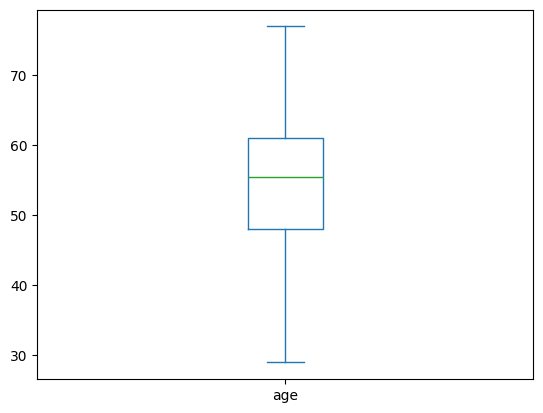

In [ ]:
# Age
df["age"].plot(kind="box") #No Outliers detected in age column.

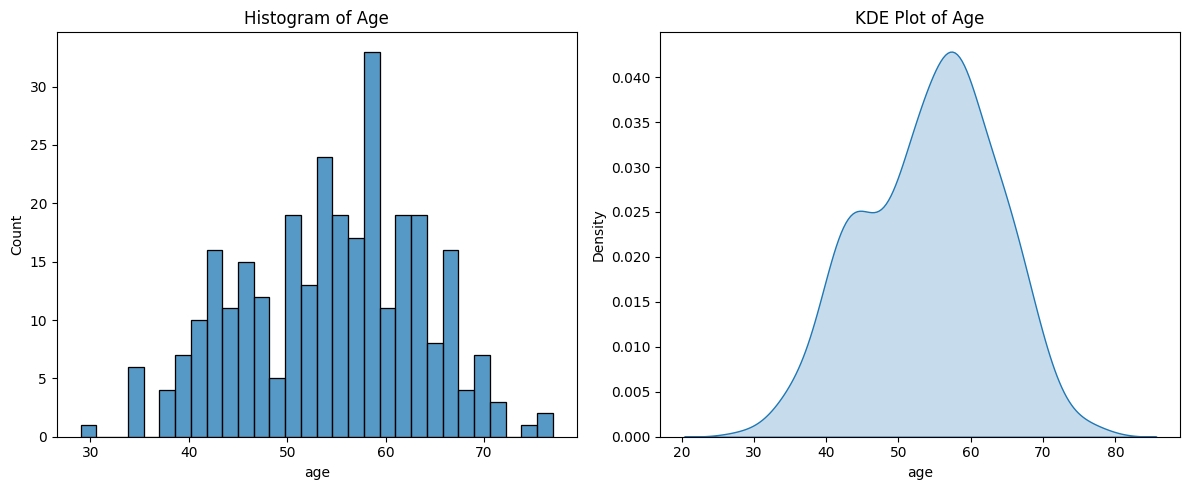

In [ ]:
#Distribution of age
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(df['age'], bins=30, ax=axes[0])
axes[0].set_title("Histogram of Age")

# KDE Plot
sns.kdeplot(df['age'], fill=True, ax=axes[1])
axes[1].set_title("KDE Plot of Age")

plt.tight_layout()
plt.show()

In [ ]:
df["age"].skew()

np.float64(-0.2037432795959691)

**INSIGHTS**

- Age column has no outliers .
- The age variable ranges from approximately 30 t0 80 years. Most patients belong to 50 t0  65 years age group with a highest concentration between 55 to 60 years.
- The distribution is approximately normal with a slight neative skew of (-0.203)


In [ ]:
# sex
df["sex"].value_counts()

,count
sex,
1,206
0,96


<Axes: xlabel='sex'>

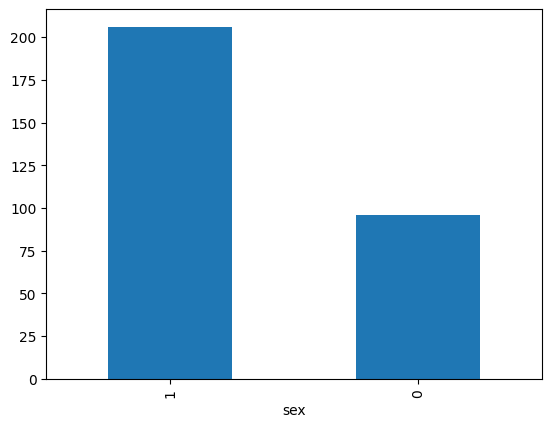

In [ ]:
df["sex"].value_counts().plot(kind="bar")

**INSIGHTS**
- Male patients are more than female patients.
- This shows a male dominated dataset.

In [ ]:
# cp
df["cp"].value_counts()

,count
cp,
0,143
2,86
1,50
3,23


<Axes: xlabel='cp'>

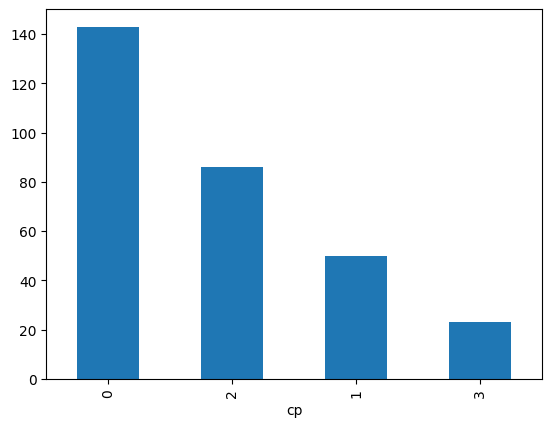

In [ ]:
df["cp"].value_counts().plot(kind="bar")

<Axes: >

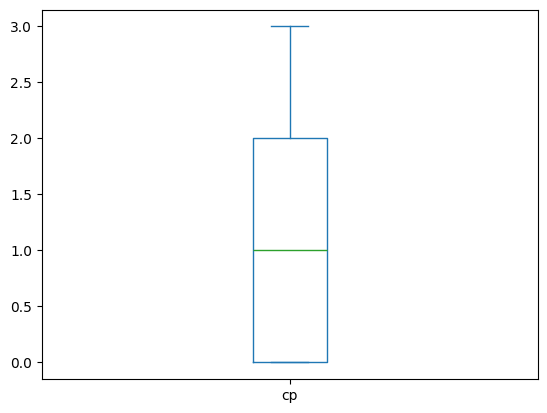

In [ ]:
df["cp"].plot(kind="box")

**Insights**
- The cp column has no outliers.
- Dataset has more patients of 0(Typical Angina).

<Axes: >

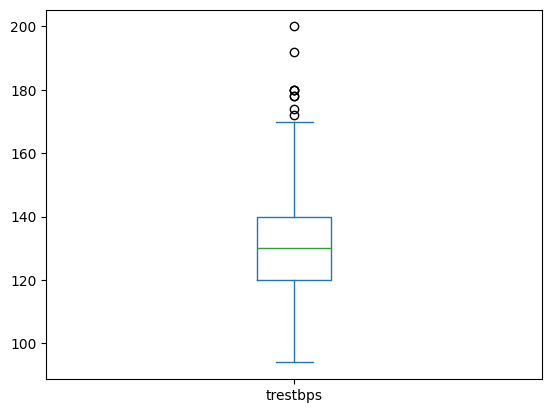

In [ ]:
df["trestbps"].plot(kind="box")

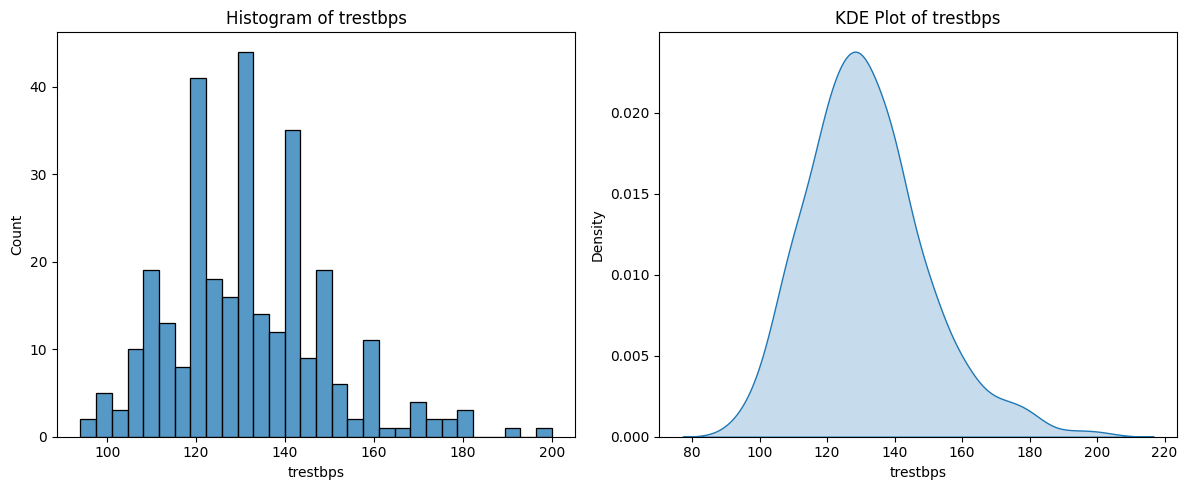

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(df['trestbps'], bins=30, ax=axes[0])
axes[0].set_title("Histogram of trestbps")

# KDE Plot
sns.kdeplot(df['trestbps'], fill=True, ax=axes[1])
axes[1].set_title("KDE Plot of trestbps")

plt.tight_layout()
plt.show()

**INSIGHTS**
- The trestbps variable has a median value of approximately 128 mmHg.
- Most observsations lie between 118 and 138 mmHg , with a fwe high value outliers present. These outliers are retained as they may represent valid clinical cases.



<Axes: >

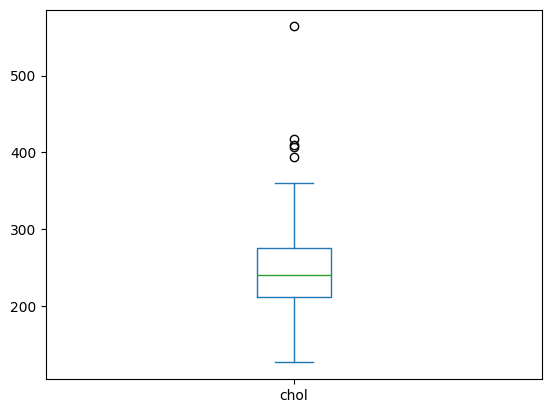

In [ ]:
#chol
df["chol"].plot(kind="box")

In [ ]:
df=df[df["chol"]<500]

Text(0.5, 1.0, 'kde for chol')

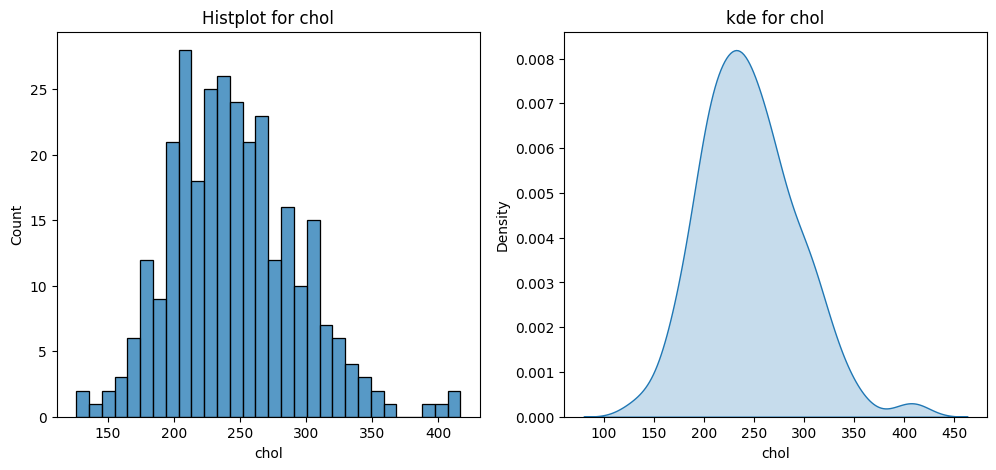

In [ ]:
fig,axes=plt.subplots(1,2, figsize=(12,5))
sns.histplot(df["chol"],bins=30,ax=axes[0])
axes[0].set_title("Histplot for chol")
sns.kdeplot(df["chol"],fill=True,ax=axes[1])
axes[1].set_title("kde for chol")

In [ ]:
df["chol"].skew()

np.float64(0.523645918715455)

**INSIGHTS**
- The chol feature exhibits a slightly right- skewed, unimodel distribution with most cholestrol values between 200 and 280mg/dl.
- A few high-value outliers are present, representing patients with exceptionally high cholestrol levels,but they may be clinically meaningful and should be retained for model development.

In [ ]:
#FBS
df["fbs"].value_counts()

,count
fbs,
0,256
1,45


<Axes: xlabel='fbs'>

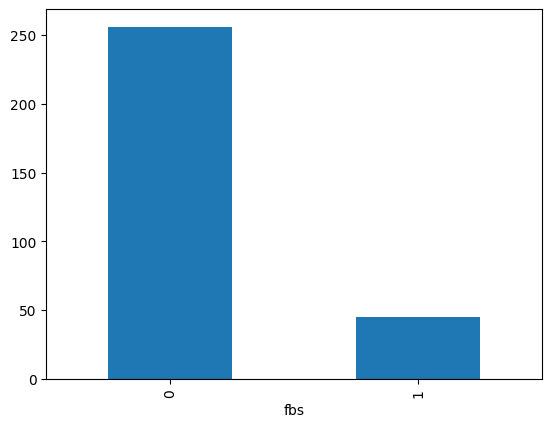

In [ ]:
df["fbs"].value_counts().plot(kind="bar")

**INSIGHTS**
- Most of the patients has fasting blood sugar 0-(<120 mg/dl) .

In [ ]:
#Restecg
df["restecg"].value_counts()


,count
restecg,
1,151
0,146
2,4


<Axes: xlabel='restecg'>

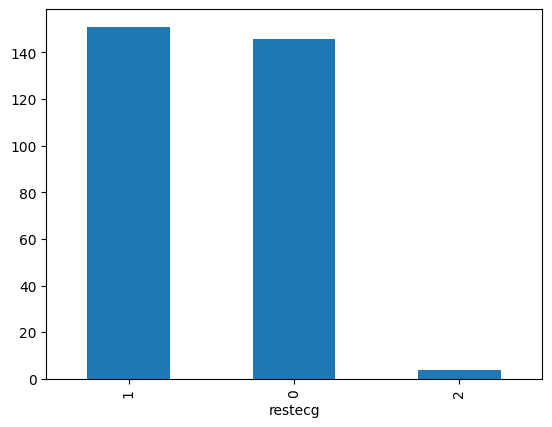

In [ ]:
df["restecg"].value_counts().plot(kind="bar")

**INSIGHTS**
- Most of the patients have (1) ST-T Wave Abnormality followed by normal(0) ecg.
- Left Ventricular Hypertrophy are(2) are very low in numberas compared  to 0 and 1 .

<Axes: >

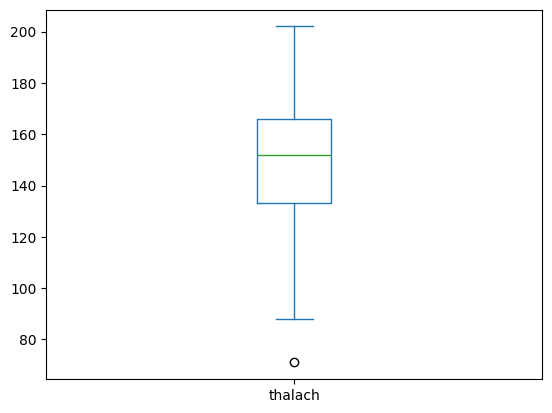

In [ ]:
#thalach
df["thalach"].plot(kind="box")

<Axes: ylabel='Density'>

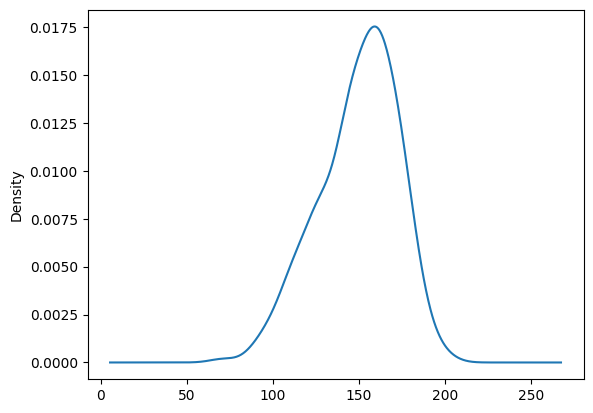

In [ ]:
df["thalach"].plot(kind="kde")

In [ ]:
df["thalach"].skew()

np.float64(-0.5281017779849069)

**INSIGHTS**
- The distribution of thalach is approximately bell-shaped with a slight negative skew.
- Most patients achieved a maximum heart rate between 140 and 170 bpm.
- No extreme outliers are observed, indicating a relatively consistent distribution of maximum heart rate among patients

In [ ]:
#exang
df["exang"].value_counts()

,count
exang,
0,202
1,99


<Axes: xlabel='exang'>

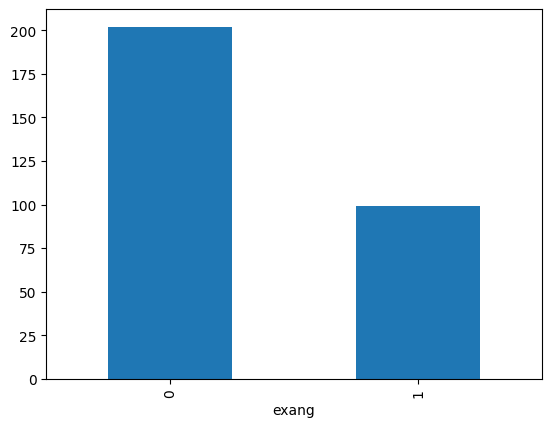

In [ ]:
df["exang"].value_counts().plot(kind="bar")

**INSIGHTS**
- Most patients have exang = 0, indicating no exercise-induced angina.
- Patients with exang = 1 are comparatively fewer.
- Since Exang is a binary categorical feature, its distribution is straightforward and no invalid categories were observed

<Axes: >

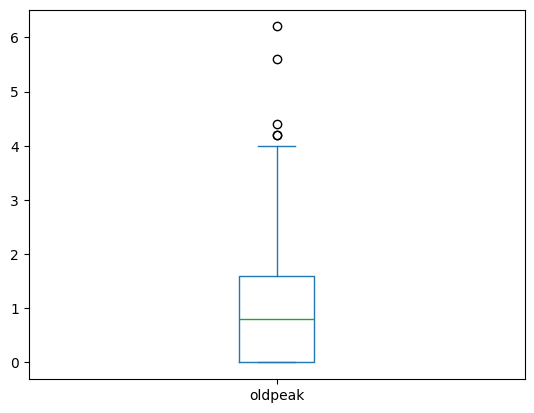

In [ ]:
#oldpeak
df["oldpeak"].plot(kind="box")

<Axes: ylabel='Density'>

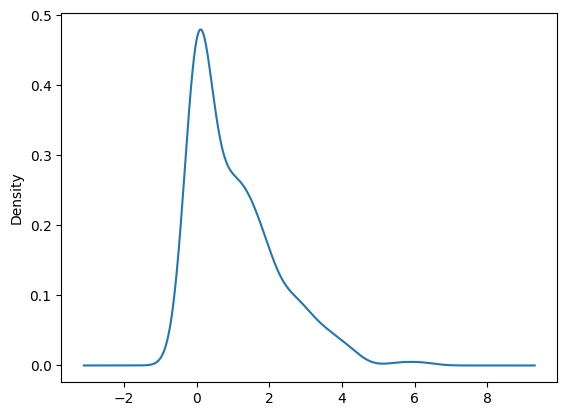

In [ ]:
df["oldpeak"].plot(kind="kde")

**INSIGHTS**
- Most patients have low oldpeak values, with many observations close to 0.
- The distribution is positively skewed, with a few patients having higher ST depression values.
- Some high-value outliers are present but are clinically meaningful and therefore retained.

In [ ]:
#slope
df["slope"].value_counts()


,count
slope,
2,141
1,139
0,21


<Axes: xlabel='slope'>

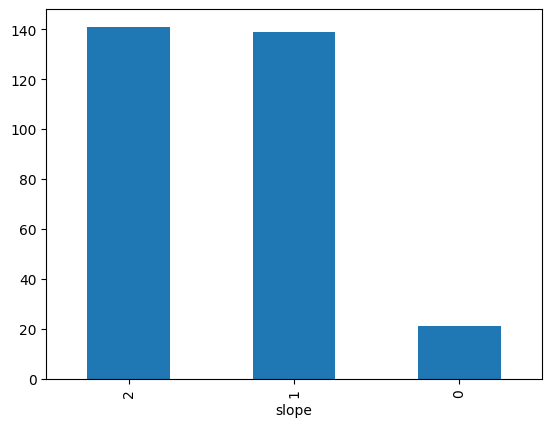

In [ ]:
df["slope"].value_counts().plot(kind="bar")

**INSIGHTS**
- The majority of patients belong to Slope = 1, followed by Slope = 2 and Slope = 0.
- The feature is categorical with an uneven class distribution.
No missing values or unusual categories are observed.

In [ ]:
#CA
df["ca"].value_counts()

,count
ca,
0,174
1,65
2,38
3,20
4,4


<Axes: xlabel='ca'>

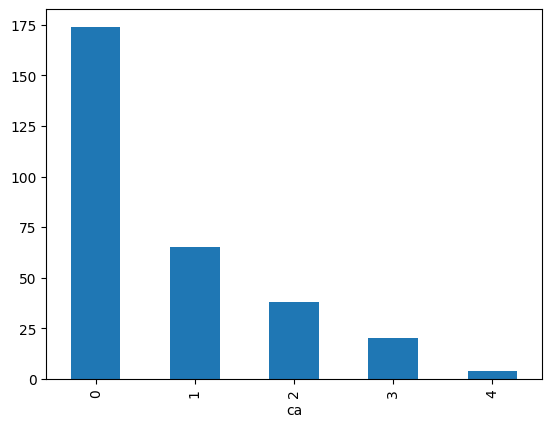

In [ ]:
df["ca"].value_counts().plot(kind='bar')

**INSIGHTS**
- Most patients have CA = 0, while higher values occur less frequently.
- The frequency decreases as the number of major vessels increases.
- The feature shows an imbalanced distribution but contains clinically meaningful information
- This imbalance is expected in clinical datasets and does not indicate a data quality problem.

In [ ]:
#thal
df["thal"].value_counts()

,count
thal,
2,165
3,116
1,18
0,2


<Axes: xlabel='thal'>

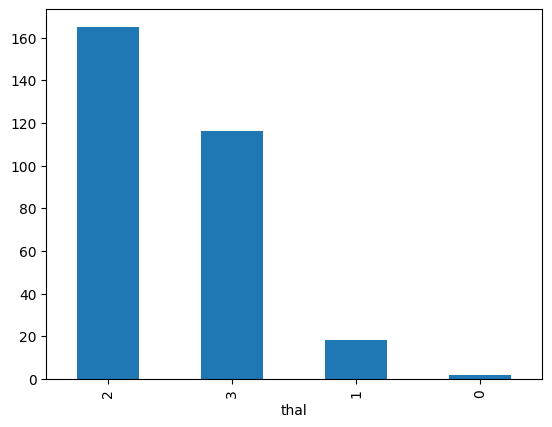

In [ ]:
df["thal"].value_counts().plot(kind='bar')

**INSIGHTS**
- The majority of patients belong to Thal = 2, followed by Thal = 3 and Thal = 1.
-  The feature is categorical with an uneven distribution across classes.
- No abnormal or invalid category values are observed.
- The presence of multiple Thal categories provides useful clinical information for distinguishing different patient conditions

## **BIVARIENT ANALYSIS**







In [ ]:
#AGE VS TARGET
df.groupby("target")["age"].mean()

,age
target,
0,56.601449
1,52.496933


<Axes: xlabel='target', ylabel='age'>

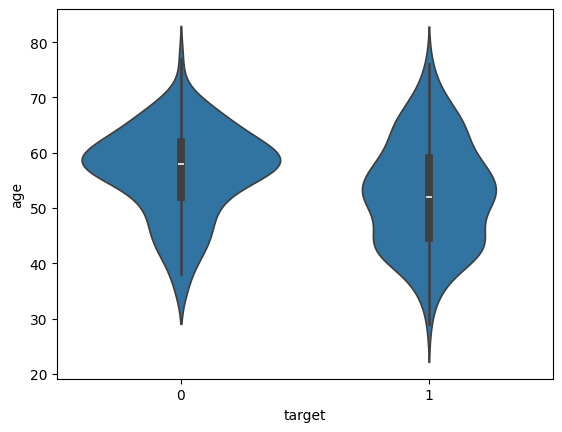

In [ ]:
sns.violinplot(x="target",y="age",data=df)

**INSIGHTS**
- The average age of Heart patient is 52 and the average age of Non- heart patient is 56.
- The median age of patuents without heart disease is slightly higher than tha of patients with heart disease in the dataset.



In [ ]:
#SEX VS TARGET
df.groupby(["sex","target"])["target"].count()

sex  target
0    0          24
     1          71
1    0         114
     1          92
Name: target, dtype: int64

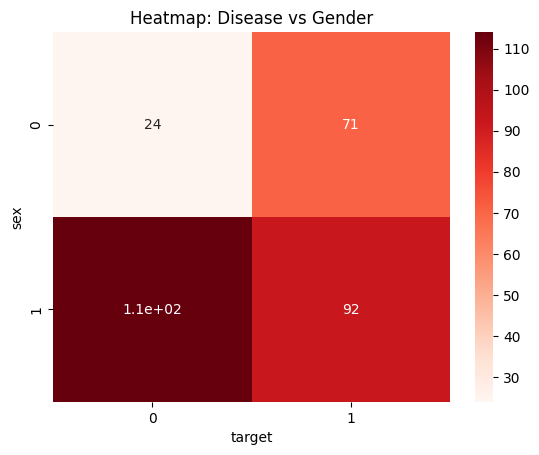

In [ ]:
data = df.groupby(["sex","target"]).size().unstack()

sns.heatmap(data, annot=True, cmap="Reds")
plt.title("Heatmap: Disease vs Gender")
plt.show()

**INSIGHTS**
- Despite the dataset containing more male patients, a greater proportion of female patients have heart disease (Target = 1) than male patients, indicating a higher prevalence of heart disease among females in this dataset.

In [ ]:
#CP AND TARGET.
df.groupby(["cp","target"])["target"].size()

cp  target
0   0         104
    1          39
1   0           9
    1          41
2   0          18
    1          67
3   0           7
    1          16
Name: target, dtype: int64

<Axes: xlabel='cp'>

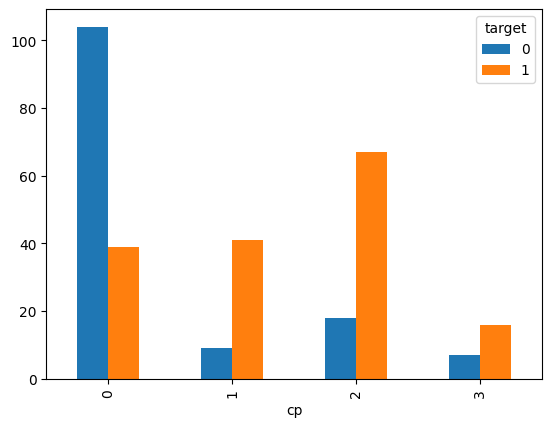

In [ ]:
pd.crosstab(df["cp"],df["target"]).plot(kind="bar")

**INSIGHTS**
- The analysis shows that chest pain type(cp) is strongly related to heart disease.
- Patients with cp-1,2 and 3 are more likely to have heart disease , while patients with cp-0 are more likely to be free  from heart disease .
- Amongg all chest pain type , cp=2 has the highest number of heart disease cases, makin chest pain type an important predictator of heart disease.

In [ ]:
# TRESTBPS VS TARGET
df.groupby("target")["trestbps"].mean()

,trestbps
target,
0,134.398551
1,129.337423


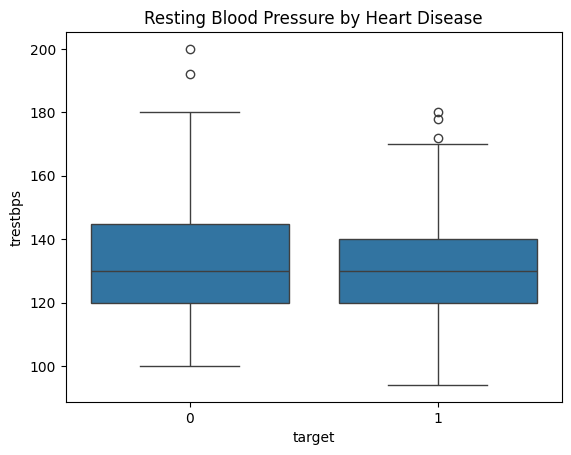

In [ ]:

sns.boxplot(x="target", y="trestbps", data=df)
plt.title("Resting Blood Pressure by Heart Disease")
plt.show()

**INSIGHTS**
- The average resting blodd pressure is 134.4mmHg for patients without heart disease and 129.3mmHg for patients with heart disease.
- The small difference and the overlappingg distribution suggest that resting blodd pressure  alone is  not a strong indicator of heart disease in this dataset.

In [ ]:
#CHOL VS  TARGET
df.groupby("target")["chol"].mean()

,chol
target,
0,251.086957
1,240.668712


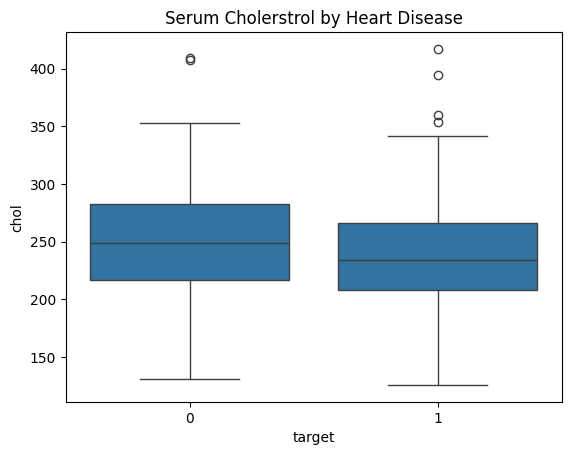

In [ ]:
sns.boxplot(x="target", y="chol", data=df)
plt.title("Serum Cholerstrol by Heart Disease")
plt.show()

**INSIGHTS**
- The average cholestrol level is 251.09 mg/dl for patients without heart disease and 242.23 mg/dl for patients with heart disease.
- Although the non-heart disease group has a slightly higher average cholestrol level, the distributions of both groups overlap significantly.
- The heart disease group contains more extreme cholestrol outliers.

In [ ]:
#FBS VS TARGET
pd.crosstab(df["target"],df["fbs"])

fbs,0,1
target,,
0,116,22
1,140,23


<Axes: xlabel='target'>

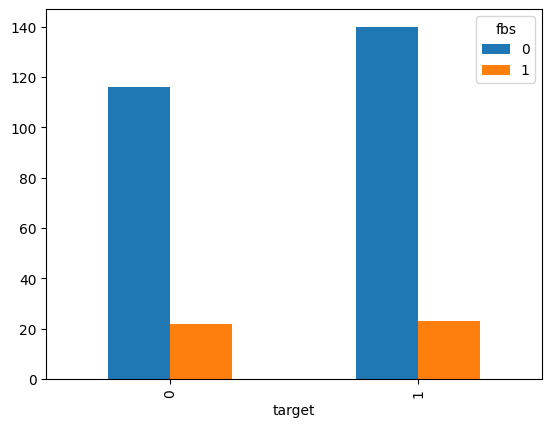

In [ ]:
pd.crosstab(df["target"],df["fbs"]).plot(kind="bar")

**INSIGHTS**
- Most patients have fasting blood sugar ≤ 120 mg/dl (fbs = 0) regardless of heart disease status.
- Very few patients have fbs = 1, making it difficult to establish a strong relationship.
- Fasting blood sugar alone does not appear to be a strong predictor of heart disease in this dataset.

In [ ]:
#RESTECG VS TARGET
pd.crosstab(df["target"],df["restecg"])


restecg,0,1,2
target,,,
0,79,56,3
1,67,95,1


<Axes: xlabel='target'>

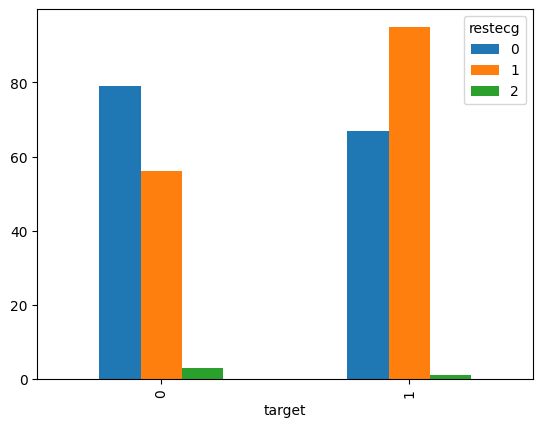

In [ ]:
pd.crosstab(df["target"],df["restecg"]).plot(kind="bar")

**INSIGHTS**
- There is a relation between restingecg results and heart disease(target).
- Patients with restecg=1 are more likely to have heart disease, while restecg=0 is slightly more common in patients without heart disease.
  



In [ ]:
#thalach VS target
df.groupby("target")["thalach"].mean()

,thalach
target,
0,139.101449
1,158.368098


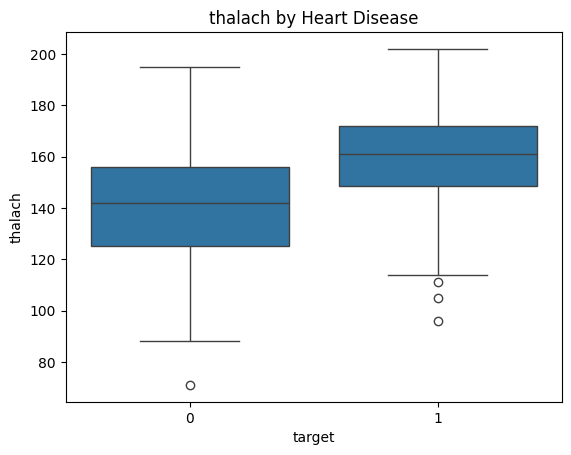

In [ ]:
sns.boxplot(x="target", y="thalach", data=df)
plt.title("thalach by Heart Disease")
plt.show()

**INSIGHTS**
- Patients with heart disease(target=1) have higgher maximum heart rate than those without heart disease.
- The median thalach is also higher for patients with heart disease.
- There  are a few low- value out;iers in both the group.

- Thalach shows a positive association with heart disease in this dataset.
- Patients diagoned with heart disease generally acheived a higher maximum heart rate than those without heart disease, indicating that thalcch may have an important  relation with the target variable.

In [ ]:
#exang VS target
pd.crosstab(df["exang"],df["target"])

target,0,1
exang,,
0,62,140
1,76,23


<Axes: xlabel='target'>

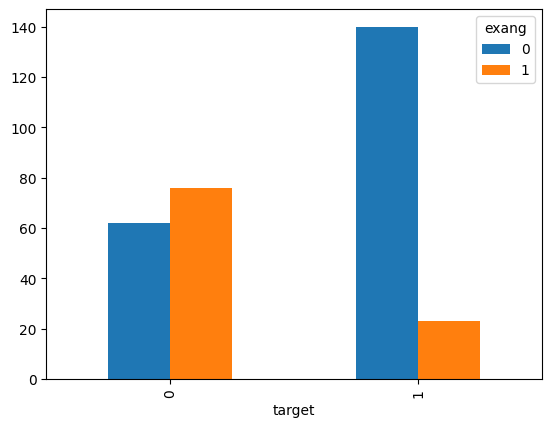

In [ ]:
pd.crosstab(df["target"],df["exang"]).plot(kind="bar")

**INSIGHTS**
- Most of the heart diease(Target=1) do not have (exang=1).
- Excercise induced angina(exang=1) is more common among patients without heart disease.
- Exang=0 is stongly associated with the presence of heart disease in this dataset.
- Exang is associated with the target variable . In this dataset, patients with exang=0 are more likely to have heart disease, while those with exang=1 are more likely to be without heart disease.


In [ ]:
#oldpeak VS target
df.groupby("target")["oldpeak"].mean()

,oldpeak
target,
0,1.585507
1,0.580368


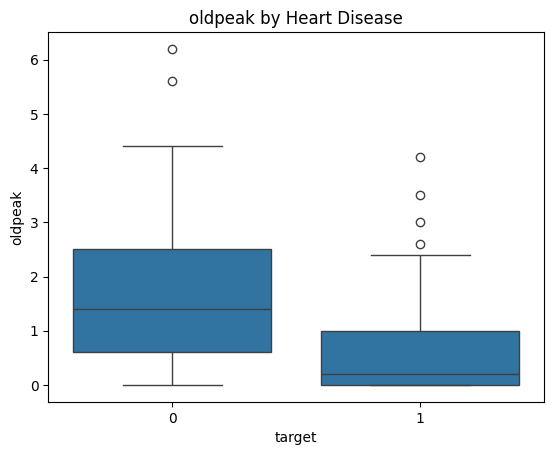

In [ ]:
sns.boxplot(x="target", y="oldpeak", data=df)
plt.title("oldpeak by Heart Disease")
plt.show()

**INSIGHTS**
- Patients with heart disease generally have higher Oldpeak values than patients without heart disease.
- Higher ST depression (Oldpeak) indicates greater likelihood of myocardial ischemia.
- Oldpeak appears to be an important feature for heart disease prediction.

In [ ]:
#SLOPE VS TARGET
pd.crosstab(df["target"],df["slope"])

slope,0,1,2
target,,,
0,12,91,35
1,9,48,106


<Axes: xlabel='target'>

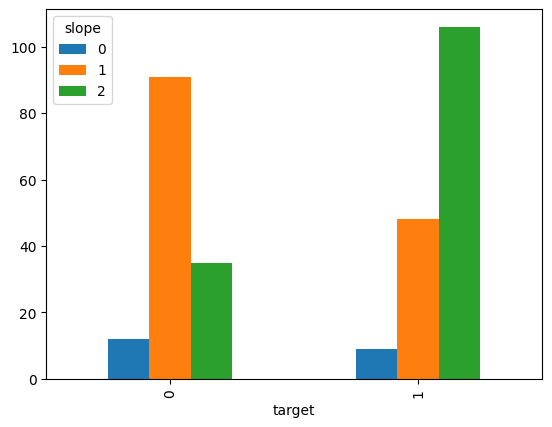

In [ ]:
pd.crosstab(df["target"],df["slope"]).plot(kind="bar")

**INSIGHTS**
- The distribution of slope differs noticeably between patients with and without heart disease.
- Certain slope categories occur more frequently among heart disease patients.
- This suggests that Slope has a meaningful relationship with the target variable and should be retained for model building.

In [ ]:
#CA VS TARGET
pd.crosstab(df["target"],df["ca"])

ca,0,1,2,3,4
target,,,,,
0,45,44,31,17,1
1,129,21,7,3,3


<Axes: xlabel='target'>

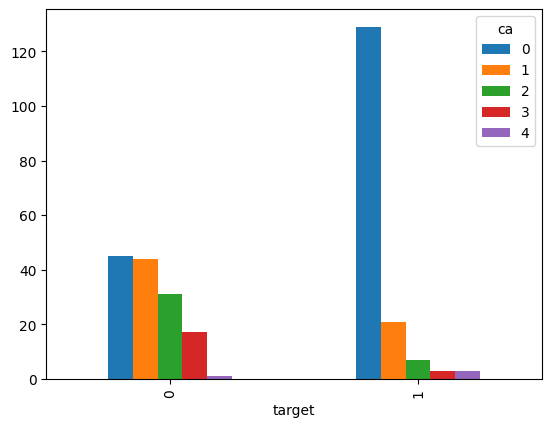

In [ ]:
pd.crosstab(df["target"],df["ca"]).plot(kind="bar")

**INSIGHTS**
- Patients with CA = 0 are the majority in the dataset.
- As the number of major vessels increases, the distribution of heart disease changes considerably.
- The CA feature shows a strong association with heart disease and is expected to be an important predictor.

In [ ]:
#THAL VS TARGET
pd.crosstab(df["target"],df["thal"])

thal,0,1,2,3
target,,,,
0,1,12,36,89
1,1,6,129,27


<Axes: xlabel='target'>

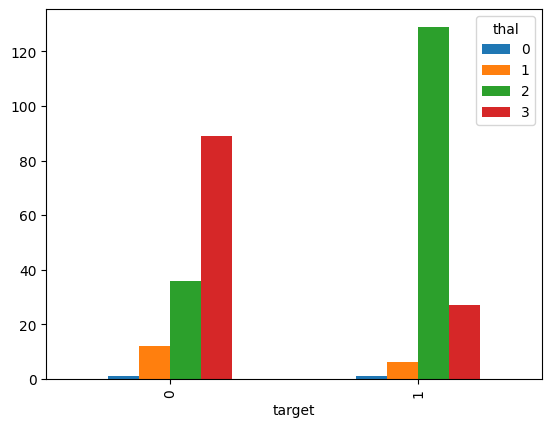

In [ ]:
pd.crosstab(df["target"],df["thal"]).plot(kind="bar")

**INSIGHTS**
- The distribution of Thal categories differs between heart disease and non-heart disease patients.
- Certain Thal values occur much more frequently among patients with heart disease.
- Thal is one of the most informative categorical variables for predicting heart disease.

# ***OVERALL CONCLUSION FROM THE EDA***
- The dataset consists of 302 patient records with 14 features, and one duplicate record was removed during preprocessing.
- The dataset contains both numerical and categorical variables, with no missing values.
- Most numerical features show reasonable distributions, while a few contain outliers that were retained because they represent valid medical observations.
- Chest Pain Type (cp), Maximum Heart Rate (thalach), Exercise-Induced Angina (exang), ST Depression (oldpeak), Number of Major Vessels (ca), and Thalassemia (thal) exhibit a strong relationship with heart disease.
- Resting Blood Pressure (trestbps), Cholesterol (chol), and Fasting Blood Sugar (fbs) show comparatively weaker relationships with the target variable.
- Female patients show a higher proportion of heart disease than males within this dataset, despite males being more numerous.
- Correlation analysis indicates that several clinical features are associated with heart disease without severe multicollinearity among predictors.
- Based on the EDA, the dataset is clean, informative, and suitable for developing machine learning models for heart disease prediction.
- Overall, the exploratory data analysis identified several clinically relevant features associated with heart disease and provided a solid foundation for building accurate machine learning classification models.

In [ ]:
#Importing Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [ ]:
# Separating dependent and independent columns
x=df.drop("target",axis=1)
y=df["target"]

In [ ]:
#Train Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

**Data Preprocessing:**
- Since the dataset was already numerically encoded, no categorical encoding was required. Only the continuous numerical features were standardized using **MinMaxScaler** to ensure they were on a comparable scale before model training.


In [ ]:
# preprocessing(scaling)
preprocessor = ColumnTransformer([
  #Scaling
    ('scale',
     MinMaxScaler(),
     ['age','trestbps','chol','thalach','oldpeak'])

], remainder='passthrough')

## ***Decision Tree Model***

In [ ]:
#Making pipeline with decision Tree
pipe =Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=chi2, k=10)),
    ('model' ,DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

In [ ]:
#Model Training
pipe.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak'])])),
                ('feature_selection',
                 SelectKBest(score_func=<function chi2 at 0x79a55ed567a0>)),
                ('model',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=2,
                                        min_samples_split=5,
                                        random_state=42))])

In [ ]:
# Model prediction
y_pred=pipe.predict(x_test)
y_pred

array([0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1])

In [ ]:
# Training and Testing Accuracy
print("Training Accuracy:", pipe.score(x_train, y_train))
print("Test Accuracy:", pipe.score(x_test, y_test))

Training Accuracy: 0.9
Test Accuracy: 0.819672131147541


In [ ]:
#Based of sample find accuracy
from sklearn.model_selection import cross_val_score
cross_val_score(pipe,x_train,y_train,cv=5,scoring="accuracy").mean()

np.float64(0.7500000000000001)

In [ ]:
# Confusion Matrix and Classification Report For Decision Tree Model.
from sklearn.metrics import classification_report, confusion_matrix

y_pred = pipe.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[19  2]
 [ 9 31]]
              precision    recall  f1-score   support

           0       0.68      0.90      0.78        21
           1       0.94      0.78      0.85        40

    accuracy                           0.82        61
   macro avg       0.81      0.84      0.81        61
weighted avg       0.85      0.82      0.82        61



##***Random Forest Model***

### Theory of Random Forest

Random Forest is a supervised machine learning algorithm used for classification and regression tasks. It is an ensemble learning method that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting. Each tree is trained on a random subset of the data and features, and the final prediction is made by majority voting (classification) or averaging (regression).

**Advantages:**

* High accuracy
* Reduces overfitting
* Handles large datasets well
* Provides feature importance

**Disadvantages:**

* Slower than a single Decision Tree
* Requires more memory
* Less interpretable due to multiple trees




In [ ]:
# pipeline using model Random Forest
pipe1 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

In [ ]:
# Model Training
pipe1.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak'])])),
                ('model',
                 RandomForestClassifier(max_depth=6, min_samples_leaf=2,
                                        min_samples_split=4, n_estimators=300,
                                        random_state=42))])

In [ ]:
#Model Prediction
y_pred=pipe1.predict(x_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1])

In [ ]:
#Training and Testing Accuracy of Model
print("Training Accuracy:", pipe1.score(x_train, y_train))
print("Test Accuracy:", pipe1.score(x_test, y_test))

Training Accuracy: 0.9666666666666667
Test Accuracy: 0.8524590163934426


In [ ]:
#Based of sample find accuracy
from sklearn.model_selection import cross_val_score
cross_val_score(pipe1,x_train,y_train,cv=5,scoring="accuracy").mean()

np.float64(0.825)

In [ ]:
#Confusion Matrix and Classification Report for Random Forest Model.
from sklearn.metrics import classification_report, confusion_matrix

y_pred = pipe1.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18  3]
 [ 6 34]]
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        21
           1       0.92      0.85      0.88        40

    accuracy                           0.85        61
   macro avg       0.83      0.85      0.84        61
weighted avg       0.86      0.85      0.85        61



# **Feature Importance and Visualisation**

In [ ]:
importance = pipe1.named_steps['model'].feature_importances_

feature_imp = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_imp)

     Feature  Importance
6    restecg    0.158730
12      thal    0.123364
11        ca    0.121004
4       chol    0.103953
3   trestbps    0.097331
0        age    0.086540
9    oldpeak    0.069987
1        sex    0.066701
2         cp    0.058631
10     slope    0.057775
5        fbs    0.029250
8      exang    0.018776
7    thalach    0.007957


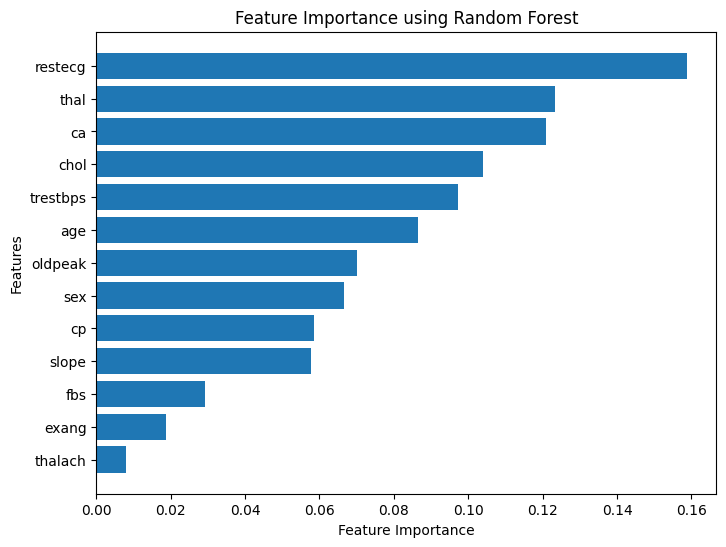

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(feature_imp['Feature'], feature_imp['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance using Random Forest")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance plot
- The feature importance plot shows that some features contribute more to predicting heart disease than others. Features with higher importance have a greater influence on the model's predictions, while features with lower importance contribute less. This analysis helps identify the most significant factors affecting heart disease prediction.

# **OVERALL VERDICT AND CONCLUSION OF THE PROJECT**

- The Heart Disease Prediction project was successfully completed by performing data cleaning, Exploratory Data Analysis (EDA), feature engineering, and model building. Since the dataset was already numerically encoded, no encoding was required. After splitting the data into training and testing sets, the continuous numerical features were scaled using **MinMaxScaler**.

- Two machine learning models, **Decision Tree** and **Random Forest**, were developed and evaluated using accuracy, confusion matrix, classification report, and cross-validation. The **Random Forest** model achieved a higher test accuracy (**85.24%**) than the **Decision Tree** (**81.96%**) and showed better precision, recall, and F1-score. Therefore, the Random Forest model was selected as the final model for heart disease prediction.

- Overall, this project demonstrates that the Random Forest algorithm is an effective and reliable approach for predicting heart disease and can assist in supporting early diagnosis and informed healthcare decisions.
